# 🌿 AgroVision Africa — Cassava Leaf Disease Classification
**Models:** ResNet-50 · EfficientNet-V2-S · ConvNeXt-Tiny  
**Device:** Apple Silicon MPS (M1/M2/M3/M4)

## 1 · Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

#  Paths 
# This notebook lives in notebooks/, project root (cassava-multitask-vision/) is one level up.
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

#  Core imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

#  Project imports (code reuse — single source of truth in codes/) 
from codes.config import (
    SEED, DEVICE, NUM_CLASSES, INPUT_SIZE,
    TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, WEIGHT_DECAY, NUM_WORKERS,
    PRETRAINED, MODEL_ARCHITECTURE, PATIENCE,
    DATA_DIR, IMAGE_DIR, MODELS_DIR, RESULTS_DIR,
)
from codes.utils import set_seed, get_device, count_parameters, format_time
from codes.data_handler import (
    CLASS_NAMES, load_label_map, CassavaDataset,
    compute_class_weights, build_weighted_sampler, per_class_f1_report,
)
from codes.model import create_model
from codes.train import Trainer
from codes.evaluate import Evaluator

#  Reproducibility & device 
set_seed(SEED)
DEVICE = get_device()

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
print(f'Seed   : {SEED}')
print(f'Data   : {DATA_DIR}')


Device : mps
Seed   : 42
Data   : /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset


## 2 · Explore the Dataset

In [2]:
# Load labels
disease_names = load_label_map(DATA_DIR)
print('Disease classes:')
for k, v in sorted(disease_names.items()):
    print(f'  {k}: {v}')

# Load CSV — handle both 'image_id' and 'img_name' column names
train_df = pd.read_csv(".."/Path(DATA_DIR) / 'train.csv')
for col in ('image_id', 'img_name', 'image', 'filename'):
    if col in train_df.columns:
        train_df = train_df.rename(columns={col: 'image_id'})
        break
train_df['image_id'] = train_df['image_id'].astype(str)

print(f'\nTotal samples: {len(train_df):,}')
display(train_df.head())

Disease classes:
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy

Total samples: 21,397


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


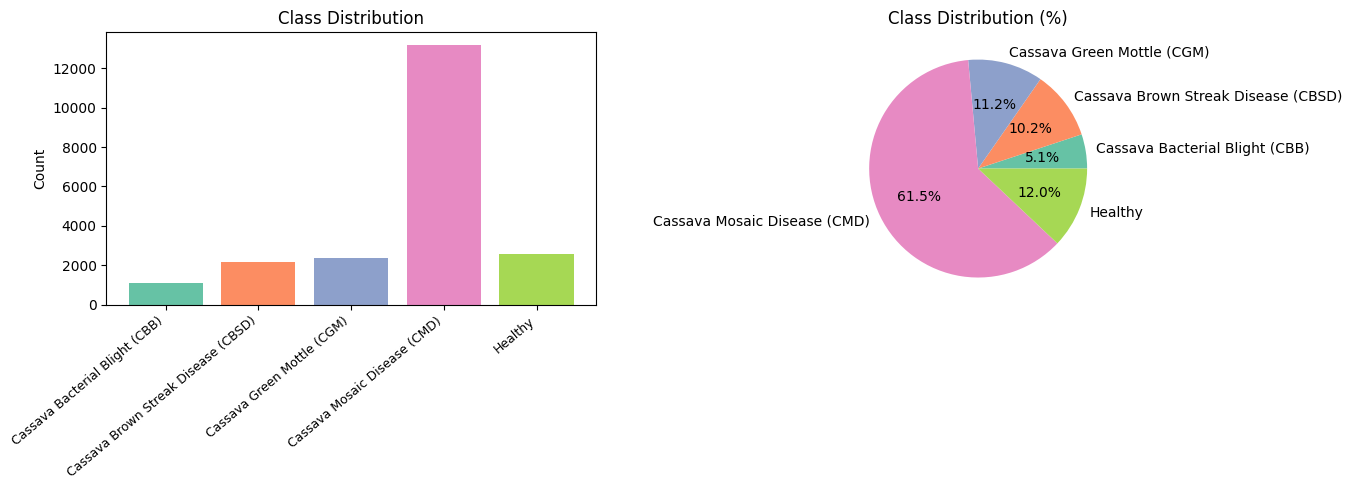

,Class,Count,Pct
0,Cassava Bacterial Blight (CBB),1087,5.1
1,Cassava Brown Streak Disease (CBSD),2189,10.2
2,Cassava Green Mottle (CGM),2386,11.2
3,Cassava Mosaic Disease (CMD),13158,61.5
4,Healthy,2577,12.0


In [3]:
# Class distribution
class_counts = train_df['label'].value_counts().sort_index()
labels_list  = [disease_names[i] for i in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(class_counts)), class_counts.values, color=sns.color_palette('Set2', len(class_counts)))
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(labels_list, rotation=40, ha='right', fontsize=9)
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=labels_list, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(class_counts)))
axes[1].set_title('Class Distribution (%)')
plt.tight_layout(); plt.show()

display(pd.DataFrame({'Class': labels_list, 'Count': class_counts.values,
                       'Pct': (class_counts.values / class_counts.sum() * 100).round(1)}))

## 3 · Outlier Detection (3-Stage Pipeline)

In [ ]:
from codes.outlier_handler import (
    run_outlier_pipeline, visualizeflagged_images,
    plot_green_fraction_distribution, plot_anomaly_score_distribution,
    apply_removals,
)

# Stage 3 uses ResNet-50 features + IsolationForest.
# Set skip_stage3=True for a fast first-pass on CPU.
PER_CLASS_THR = -0.15   # lower → more flags
SKIP_STAGE3   = False   # set True to skip GPU embedding step

(
    df_clean,   # Stage-1 manifest (integrity failures removed)
    stats_df,   # Stage-2 pixel stats
    flagged2,   # Stage-2 non-leaf candidates
    feats,      # Stage-3 PCA embeddings
    emb_ids,    # Stage-3 image IDs
    scores,     # Stage-3 per-class IF scores
    flagged3,   # Stage-3 embedding outliers
) = run_outlier_pipeline(
    csv_path      = str(DATA_DIR / 'train.csv'),
    img_dir       = str(IMAGE_DIR),
    device        = str(DEVICE),
    per_class_thr = PER_CLASS_THR,
    skip_stage3   = SKIP_STAGE3,
)


Loaded: 21,397 images - 5 classes
------------------------------------------------------------


[Stage 1] Integrity audit: 100%|██████████| 21397/21397 [00:59<00:00, 362.53it/s]



[Stage 1] Auto-removed 0 / 21,397 images


[Stage 2] Leaf-content stats: 100%|██████████| 21397/21397 [01:27<00:00, 243.31it/s]



[Stage 2] Flagged 36 / 21,397 images as not leaf-like
  -> saved: results/review_stage2_nonleaf.csv


[Stage 3] Feature extraction: 100%|██████████| 335/335 [03:09<00:00,  1.77it/s]



[Stage 3] Flagged 83 / 21,397 images (per-class IsolationForest, thr=-0.15)
  -> saved: results/review_stage3_embedding.csv

------------------------------------------------------------
PIPELINE COMPLETE
------------------------------------------------------------
  After Stage 1      : 21,397
  Stage 2 flagged    : 36  -> review_stage2_nonleaf.csv
  Stage 3 flagged    : 83  -> review_stage3_embedding.csv

NEXT STEPS:
  1. visualizeFLAGged_images(flagged2, img_dir, title='Stage 2 - not leaf-like')
  2. visualizeFLAGged_images(flagged3, img_dir, title='Stage 3 - embedding outliers')
  3. plot_green_fraction_distribution(stats_df, flagged2)  # tune threshold if needed
  4. plot_anomaly_score_distribution(scores, per_class_thr)
  5. Build remove_ids list from confirmed outliers, then:
     final_df = apply_removals(df, remove_ids)
------------------------------------------------------------



In [5]:
# Stage 1 results
s1_log = RESULTS_DIR / 'removed_stage1_integrity.csv'
if s1_log.exists():
    s1_df = pd.read_csv(s1_log)
    print(f'Auto-removed: {len(s1_df):,}')
    display(s1_df['reason'].str.split('(').str[0].value_counts().to_frame())
else:
    print('All images passed Stage 1 ✓')
print(f'Surviving: {len(df_clean):,}')

All images passed Stage 1 ✓
Surviving: 21,397


Stage 2 flagged: 36 / 21,397


,image_id,label,green_fraction,saturation_mean,fail_reasons
0,1366430957.jpg,1,0.022115,54.441399,low_green=0.022
1,1689510013.jpg,1,0.015454,23.138630,low_green=0.015
2,1726694302.jpg,1,0.010806,68.364319,low_green=0.011
3,1760495628.jpg,4,0.025504,107.917984,low_green=0.026
4,1848686439.jpg,1,0.024871,85.919380,low_green=0.025
5,1960041118.jpg,1,0.035987,129.078735,low_green=0.036
6,199112616.jpg,1,0.027077,106.855698,low_green=0.027
7,2073193450.jpg,1,0.038137,103.297417,low_green=0.038
8,2139839273.jpg,1,0.031492,92.901535,low_green=0.031
9,2142361151.jpg,1,0.032875,101.326805,low_green=0.033


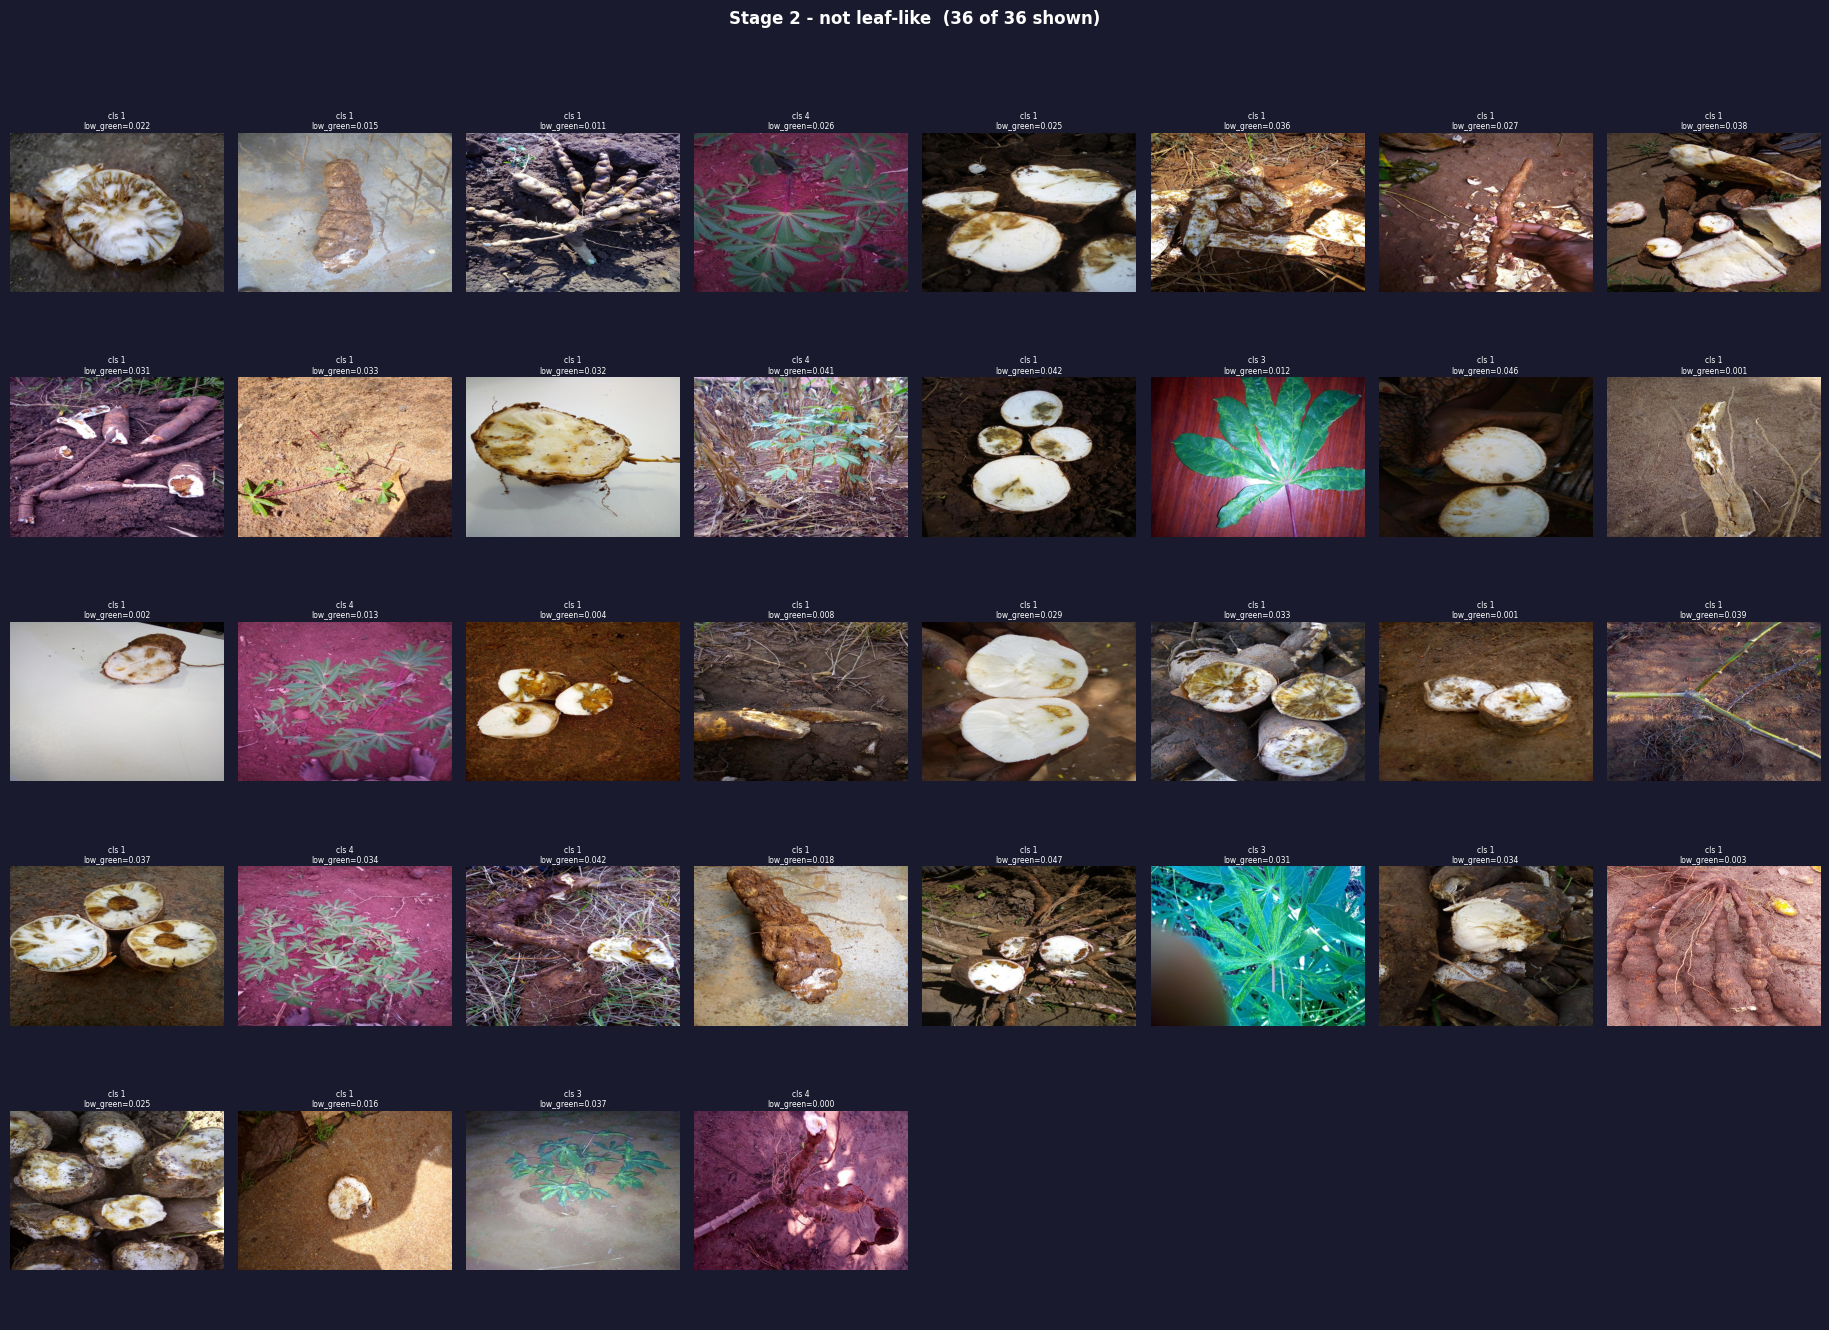

In [8]:
# Stage 2 — review flagged non-leaf images
print(f'Stage 2 flagged: {len(flagged2):,} / {len(stats_df):,}')
if not flagged2.empty:
    display(flagged2[['image_id', 'label', 'green_fraction', 'saturation_mean', 'fail_reasons']].head(20))
    visualizeflagged_images(flagged2, str(IMAGE_DIR), title='Stage 2 - not leaf-like')
    plot_green_fraction_distribution(stats_df, flagged2,
        save_path=str(RESULTS_DIR / 'stage2_green_dist.png'))

Stage 3 flagged: 83


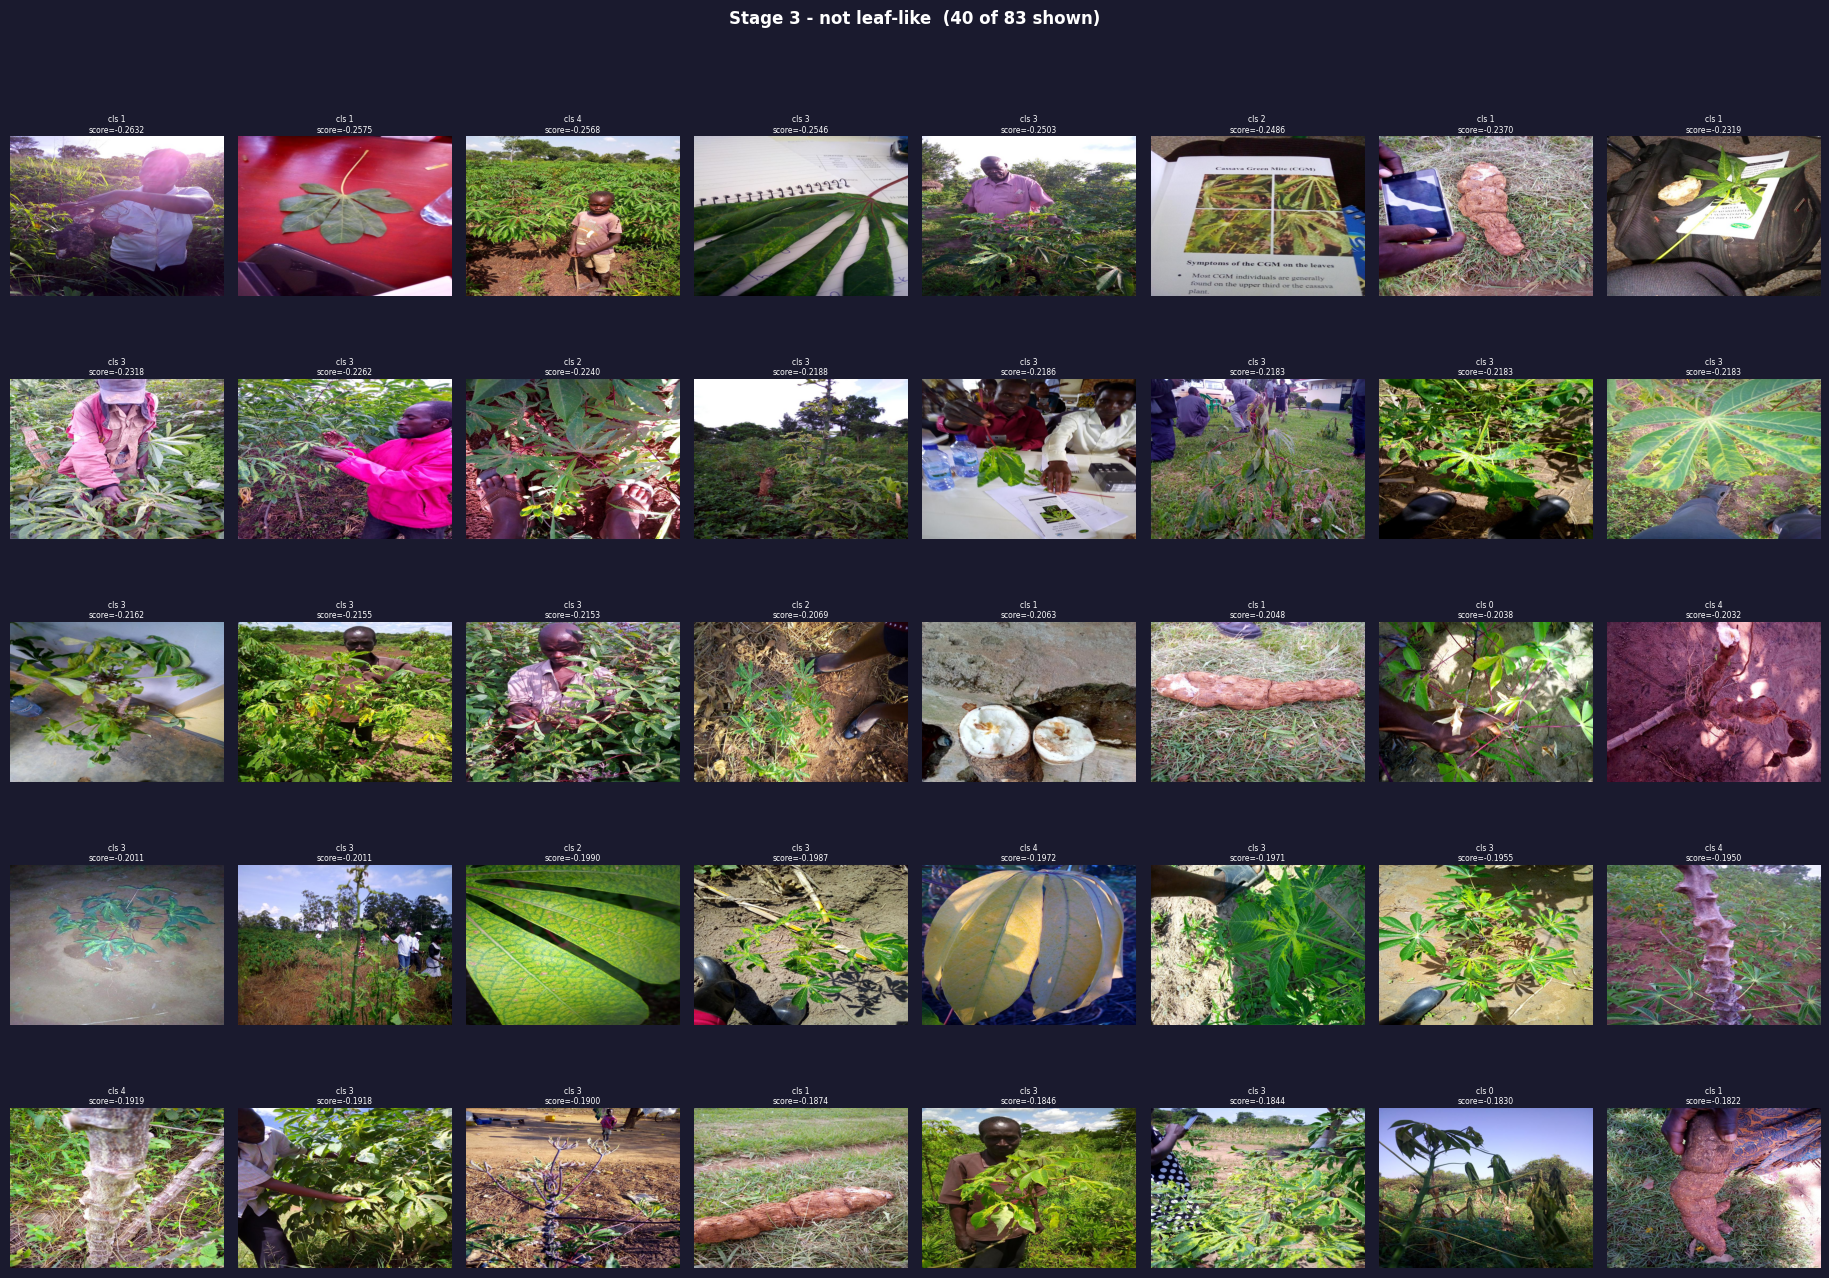

Using df_clean from Stage 1 for training.


In [9]:
# Stage 3 — embedding outliers
if not SKIP_STAGE3 and len(scores) > 0:
    print(f'Stage 3 flagged: {len(flagged3):,}')
    plot_anomaly_score_distribution(scores, thr=PER_CLASS_THR,
        save_path=str(RESULTS_DIR / 'stage3_anomaly_dist.png'))
    visualizeflagged_images(flagged3, str(IMAGE_DIR), title='Stage 3 - not leaf-like')

#  ACTION: After visual review, build remove_ids and call apply_removals 
# Example:
#   remove_ids = ['img1.jpg', 'img2.jpg']  # confirmed outliers
#   df_clean   = apply_removals(df_clean, remove_ids, str(RESULTS_DIR/'train_clean.csv'))
# For now we proceed with df_clean from Stage 1 only.
print('Using df_clean from Stage 1 for training.')

## 4 · Data Splits & DataLoaders

In [11]:
# Stratified train / val / test split, ratios from config.py
val_test_size = VAL_SPLIT + TEST_SPLIT
train_idx, temp_idx = train_test_split(
    range(len(df_clean)), test_size=val_test_size, random_state=SEED,
    stratify=df_clean['label'])

# Split the remaining (val+test) proportionally
test_fraction_of_temp = TEST_SPLIT / val_test_size
val_idx, test_idx = train_test_split(
    temp_idx, test_size=test_fraction_of_temp, random_state=SEED,
    stratify=df_clean.iloc[temp_idx]['label'])

split_df = {
    'train': df_clean.iloc[train_idx].reset_index(drop=True),
    'val':   df_clean.iloc[val_idx].reset_index(drop=True),
    'test':  df_clean.iloc[test_idx].reset_index(drop=True),
}
for k, df in split_df.items():
    print(f'{k:5s}: {len(df):,} samples')

train: 17,117 samples
val  : 2,140 samples
test : 2,140 samples


In [ ]:
# Class-weighted sampler for train (alternative to weighted loss; both reuse data_handler)
sampler = build_weighted_sampler(split_df['train'], NUM_CLASSES)

# num_workers=0 avoids multiprocessing hangs on macOS
LOADER_KWARGS = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=False)

loaders = {
    'train': DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True,  image_size=INPUT_SIZE),
        sampler=sampler, **LOADER_KWARGS),
    'val':   DataLoader(
        CassavaDataset(split_df['val'],   IMAGE_DIR, augment=False, image_size=INPUT_SIZE),
        shuffle=False, **LOADER_KWARGS),
    'test':  DataLoader(
        CassavaDataset(split_df['test'],  IMAGE_DIR, augment=False, image_size=INPUT_SIZE),
        shuffle=False, **LOADER_KWARGS),
}

# Sanity check
imgs, lbs = next(iter(loaders['train']))
print(f'Batch shape: {imgs.shape}  Labels: {lbs.shape}')
print(f'Pixel range: [{imgs.min():.2f}, {imgs.max():.2f}]')

Batch shape: torch.Size([32, 3, 224, 224])  Labels: torch.Size([32])
Pixel range: [-2.12, 2.64]


## 5 · Model Selection
> Choose one of: `resnet50` · `efficientnet_v2_s` · `convnext_tiny`

In [ ]:
#  Select model here 
MODEL_NAME = MODEL_ARCHITECTURE   # from config.py (default: 'efficientnet_v2_s')
# MODEL_NAME = 'resnet50'
# MODEL_NAME = 'convnext_tiny'

model = create_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED, model_name=MODEL_NAME)
model = model.to(DEVICE)

total_params     = count_parameters(model)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Model          : {MODEL_NAME}')
print(f'Total params   : {total_params:,}')
print(f'Trainable      : {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')
print(f'Device         : {DEVICE}')

### Optional: Two-phase training (freeze → unfreeze backbone)

In [ ]:
# Phase 1: freeze backbone, warm up the head only (optional)
# model.freeze_backbone()
# trainer_warmup = Trainer(model, device, learning_rate=1e-3, weight_decay=WEIGHT_DECAY,
#                          class_weights=compute_class_weights(split_df['train'], NUM_CLASSES))
# trainer_warmup.train(loaders['train'], loaders['val'], num_epochs=5, patience=3,
#                      model_save_dir=str(MODELS_DIR))
# model.unfreeze_backbone()   # Phase 2: fine-tune everything
print('(Two-phase training commented out — uncomment to use)')

## 6 · Train

In [ ]:
from codes.loss import build_criterion
# Loss function selection 
# compute_class_weights returns inverse-frequency weights (auto-normalised).
# When using WeightedRandomSampler above, pass alpha=None to avoid double-correction.
# When NOT using a sampler, pass alpha=class_weights_tensor.

class_weights = compute_class_weights(split_df['train'], NUM_CLASSES)
print('Inverse-frequency class weights:', class_weights.numpy().round(3))

# Choose loss type 
# SAMPLER active  → set LOSS_TYPE='focal' with alpha=None (no class-weight in loss)
# SAMPLER inactive → set LOSS_TYPE='focal' or 'weighted_ce' with class_weights
LOSS_TYPE = 'focal'   # 'focal' | 'weighted_ce'
FOCAL_GAMMA = 2.0     # 0 → plain CE; 2 → standard focal; 3 → aggressive minority focus

# Because the WeightedRandomSampler already handles imbalance, we pass alpha=None here.
# Swap to `alpha=class_weights.to(device)` if you disable the sampler.
criterion = build_criterion(LOSS_TYPE, class_weights=None, gamma=FOCAL_GAMMA)
print(f'Loss function : {criterion.__class__.__name__}  (gamma={FOCAL_GAMMA})')

# Two-phase training 
# Phase 1: train head only (backbone frozen) for WARMUP_EPOCHS epochs.
# Phase 2: unfreeze and fine-tune the full network at a lower LR.
WARMUP_EPOCHS = 5   # head-only warm-up
WARMUP_LR     = 1e-3

print(f'\nPhase 1 — head warm-up ({WARMUP_EPOCHS} epochs, LR={WARMUP_LR})')
model.freeze_backbone()
trainer_warmup = Trainer(
    model         = model,
    device        = DEVICE,
    learning_rate = WARMUP_LR,
    weight_decay  = WEIGHT_DECAY,
    criterion     = criterion,
)
history_warmup = trainer_warmup.train(
    train_loader   = loaders['train'],
    val_loader     = loaders['val'],
    num_epochs     = WARMUP_EPOCHS,
    patience       = PATIENCE,
    model_save_dir = str(MODELS_DIR),
)

print(f'\nPhase 2 — full fine-tune (LR={LEARNING_RATE})')
model.unfreeze_backbone()
trainer = Trainer(
    model         = model,
    device        = DEVICE,
    learning_rate = LEARNING_RATE,
    weight_decay  = WEIGHT_DECAY,
    criterion     = criterion,
)
history = trainer.train(
    train_loader   = loaders['train'],
    val_loader     = loaders['val'],
    num_epochs     = NUM_EPOCHS,
    patience       = PATIENCE,
    model_save_dir = str(MODELS_DIR),
)

# Merge histories for unified plotting
for key in history_warmup:
    history[key] = history_warmup[key] + history[key]
print('Training complete. Best checkpoint saved to', MODELS_DIR / 'best_model.pth')


In [ ]:
# Training curves
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['lr'])
axes[2].set_title('Learning Rate (CosineAnnealing)'); axes[2].set_xlabel('Epoch')

for ax in axes: ax.grid(True, alpha=0.3)
plt.suptitle(f'{MODEL_NAME} — Training Curves', fontsize=13)
plt.tight_layout(); plt.show()

## 7 · Evaluate on Test Set

In [ ]:
# Load best checkpoint
ckpt = MODELS_DIR / 'best_model.pth'
model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
print(f'Loaded: {ckpt}')

evaluator = Evaluator(
    num_classes  = NUM_CLASSES,
    class_names  = [disease_names.get(i, f'Class {i}') for i in range(NUM_CLASSES)],
    device       = DEVICE,
)

results = evaluator.evaluate(model, loaders['test'])
m       = results['metrics']

print(f"\n{'Metric':<12} {'Score':>8}")
print('-' * 22)
for metric, val in m.items():
    print(f"{metric:<12} {val:>8.4f}")

In [ ]:
# Per-class F1 report
f1_report = per_class_f1_report(results['true_labels'].tolist(),
                                 results['predictions'].tolist(), NUM_CLASSES)
display(f1_report)
failing = f1_report[f1_report['f1'] < 0.80]
if not failing.empty:
    print('⚠️  Classes with F1 < 0.80 (need attention):')
    print(failing[['class','f1','support']].to_string(index=False))

In [ ]:
# Full sklearn classification report
evaluator.print_report(results['true_labels'], results['predictions'])

In [ ]:
# Confusion matrices: raw counts + normalized
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plt.sca(axes[0])
evaluator.plot_confusion_matrix(results['true_labels'], results['predictions'],
                                 normalize=False)
plt.sca(axes[1])
evaluator.plot_confusion_matrix(results['true_labels'], results['predictions'],
                                 normalize=True)
plt.tight_layout(); plt.show()

In [ ]:
# Save results
summary = {k: float(v) for k, v in m.items()}
summary.update({'model': MODEL_NAME, 'test_samples': int(len(results['true_labels']))})

import json
out_path = RESULTS_DIR / 'evaluation_metrics.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=4)
print(f'Results saved → {out_path}')
print(json.dumps(summary, indent=4))

## 8 · Model Comparison (Run All Three)
Run this section to benchmark all three backbones and compare performance.

In [ ]:
COMPARE_MODELS = False   # set True to train all three and compare

if COMPARE_MODELS:
    import time
    comparison = []

    for name in ['resnet50', 'efficientnet_v2_s', 'convnext_tiny']:
        print(f'\n{'='*60}')
        print(f'Training: {name}')
        print('='*60)

        m = create_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED, model_name=name).to(DEVICE)
        t = Trainer(m, DEVICE, learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
                    class_weights=class_weights)
        t0 = time.time()
        t.train(loaders['train'], loaders['val'], num_epochs=NUM_EPOCHS,
                patience=PATIENCE, model_save_dir=str(MODELS_DIR / name))
        elapsed = time.time() - t0

        m.load_state_dict(torch.load(MODELS_DIR / name / 'best_model.pth', map_location=DEVICE))
        ev   = Evaluator(NUM_CLASSES, [disease_names[i] for i in range(NUM_CLASSES)], DEVICE)
        res  = ev.evaluate(m, loaders['test'])
        met  = res['metrics']
        comparison.append({'model': name, **{k: round(v, 4) for k, v in met.items()},
                           'params_M': round(count_parameters(m) / 1e6, 2),
                           'train_min': round(elapsed / 60, 1)})

    comp_df = pd.DataFrame(comparison).sort_values('f1', ascending=False)
    display(comp_df)

## 8b · Ablation Study — Loss Function & Imbalance Strategy

The cell below trains the selected architecture three times with different
imbalance-handling settings to quantify each component's contribution.
Set `RUN_ABLATION = True` to execute (adds ~3× training time).


In [ ]:
RUN_ABLATION = False   # set True to run the ablation study

if RUN_ABLATION:
    import time
    ablation_results = []

    ablation_configs = [
        # (loss_type,    use_sampler, focal_gamma, label)
        ('weighted_ce', False,       0.0,         'WeightedCE  / no sampler'),
        ('focal',       False,       2.0,         'FocalLoss γ=2 / no sampler'),
        ('focal',       True,        2.0,         'FocalLoss γ=2 + sampler  ← default'),
    ]

    for loss_type, use_sampler, gamma, label in ablation_configs:
        print(f'\n{"="*60}')
        print(f'Config: {label}')
        print('='*60)

        # Fresh model
        m_ab = create_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED,
                            model_name=MODEL_NAME).to(DEVICE)

        # DataLoader
        if use_sampler:
            samp = build_weighted_sampler(split_df['train'], NUM_CLASSES)
            tl   = DataLoader(CassavaDataset(split_df['train'], IMAGE_DIR, augment=True,
                              image_size=INPUT_SIZE), sampler=samp, **LOADER_KWARGS)
            w_for_loss = None   # sampler already balances; don't double-correct
        else:
            tl   = DataLoader(CassavaDataset(split_df['train'], IMAGE_DIR, augment=True,
                              image_size=INPUT_SIZE), shuffle=True, **LOADER_KWARGS)
            w_for_loss = class_weights   # no sampler → pass weights into loss

        crit = build_criterion(loss_type, class_weights=w_for_loss, gamma=gamma)

        t_ab = Trainer(m_ab, DEVICE, learning_rate=LEARNING_RATE,
                       weight_decay=WEIGHT_DECAY, criterion=crit)
        t0 = time.time()
        t_ab.train(loaders['train'], loaders['val'], num_epochs=NUM_EPOCHS,
                   patience=PATIENCE, model_save_dir=str(MODELS_DIR / 'ablation' / label))
        elapsed = time.time() - t0

        m_ab.load_state_dict(torch.load(
            MODELS_DIR / 'ablation' / label / 'best_model.pth', map_location=DEVICE))
        ev_ab  = Evaluator(NUM_CLASSES, [disease_names[i] for i in range(NUM_CLASSES)], DEVICE)
        res_ab = ev_ab.evaluate(m_ab, loaders['test'])
        met_ab = res_ab['metrics']

        ablation_results.append({
            'config': label,
            **{k: round(v, 4) for k, v in met_ab.items()},
            'train_min': round(elapsed / 60, 1),
        })
        print(f"  macro-F1={met_ab['f1']:.4f}  acc={met_ab['accuracy']:.4f}")

    ablation_df = pd.DataFrame(ablation_results).sort_values('f1', ascending=False)
    print('\n── Ablation results ────────────────────────────────────────────')
    display(ablation_df)


## 9 · Explainability — Grad-CAM
Grad-CAM (Selvaraju et al., 2017) highlights the image regions that
most influenced the model's prediction, useful for error analysis
(why a sample was misclassified) and for building trust in the model.


In [ ]:
from codes.gradcam import show_gradcam, show_gradcam_grid
import cv2

# A few correctly- and incorrectly-classified test samples
n_examples = 8
sample_idx = np.random.RandomState(SEED).choice(len(split_df['test']), size=n_examples, replace=False)

images, true_labels_sample = [], []
for idx in sample_idx:
    row = split_df['test'].iloc[idx]
    img_bgr = cv2.imread(str(IMAGE_DIR / row['image_id']))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images.append(img_rgb)
    true_labels_sample.append(int(row['label']))

show_gradcam_grid(
    model       = model,
    model_name  = MODEL_NAME,
    images      = images,
    image_size  = INPUT_SIZE,
    class_names = disease_names,
    device      = DEVICE,
    true_labels = true_labels_sample,
    cols        = 4,
)


### Single-image Grad-CAM
Detailed Grad-CAM for one image, showing input, raw heatmap, and overlay side by side.

In [ ]:
row = split_df['test'].iloc[sample_idx[0]]
img_bgr = cv2.imread(str(IMAGE_DIR / row['image_id']))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show_gradcam(
    model       = model,
    model_name  = MODEL_NAME,
    image       = img_rgb,
    image_size  = INPUT_SIZE,
    class_names = disease_names,
    device      = DEVICE,
    true_label  = int(row['label']),
)


### Focused error analysis — misclassified samples
Combine Grad-CAM with the confusion matrix: visualize *only* the
misclassified test samples to inspect what the model is attending to
when it gets a prediction wrong.


In [ ]:
# Identify misclassified test samples
y_true = results['true_labels']
y_pred = results['predictions']
misclassified_mask = y_true != y_pred
misclassified_positions = np.where(misclassified_mask)[0]

print(f'Misclassified: {len(misclassified_positions):,} / {len(y_true):,} '
      f'({misclassified_mask.mean()*100:.1f}%)')

n_show = min(8, len(misclassified_positions))
if n_show > 0:
    show_pos = np.random.RandomState(SEED).choice(misclassified_positions, size=n_show, replace=False)

    err_images, err_true = [], []
    for pos in show_pos:
        row = split_df['test'].iloc[pos]
        img_bgr = cv2.imread(str(IMAGE_DIR / row['image_id']))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        err_images.append(img_rgb)
        err_true.append(int(row['label']))

    show_gradcam_grid(
        model       = model,
        model_name  = MODEL_NAME,
        images      = err_images,
        image_size  = INPUT_SIZE,
        class_names = disease_names,
        device      = DEVICE,
        true_labels = err_true,
        cols        = 4,
    )
else:
    print('No misclassified samples to visualize 🎉')


### 9b · In-Depth Error Analysis — Confused Classes

Identify which class pairs the model confuses most and print representative
failure cases with their predicted vs. true label.


In [ ]:
#  Confused-class analysis 
import itertools

y_true_np = np.array(results['true_labels'])
y_pred_np = np.array(results['predictions'])

# Count (true, predicted) confusion pairs for misclassified samples
conf_pairs = {}
for t, p in zip(y_true_np[y_true_np != y_pred_np],
                y_pred_np[y_true_np != y_pred_np]):
    key = (int(t), int(p))
    conf_pairs[key] = conf_pairs.get(key, 0) + 1

conf_pairs_sorted = sorted(conf_pairs.items(), key=lambda x: -x[1])

print(f"{'True class':<40} {'Predicted as':<40} {'Count':>6}")
print('-' * 90)
for (t, p), cnt in conf_pairs_sorted[:10]:
    t_name = disease_names.get(t, f'Class {t}')
    p_name = disease_names.get(p, f'Class {p}')
    print(f"{t_name:<40} {p_name:<40} {cnt:>6}")

# Per-class recall
print("\n── Per-class recall on test set ───────────────────────────────────")
for cls in range(NUM_CLASSES):
    mask = y_true_np == cls
    if mask.sum() == 0:
        continue
    recall = (y_pred_np[mask] == cls).mean()
    name   = disease_names.get(cls, f'Class {cls}')
    bar    = '█' * int(recall * 30)
    print(f"  {name:<40s} recall={recall:.3f}  |{bar}")


## 10 · Demo

A Streamlit demo (`app.py`, project root) reuses `config.py`,
`data_handler.py`, `model.py`, and `utils.py` to load the best
checkpoint and classify an uploaded leaf image. Run it with:

```bash
streamlit run app.py
```
